In [1]:
import pandas as pd
import numpy as np
import cupy as cp
import optuna

# Модели
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.svm import SVC as cuSVC  # Заменили LogReg на SVM
from sklearn.model_selection import StratifiedKFold
from cuml.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

/home/admingwi/anaconda3/envs/rapids_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.metrics import f1_score, precision_recall_curve

def get_metrics(y_true, y_prob, prefix=""):
    # Переводим данные в numpy, так как sklearn не всегда дружит с cupy напрямую
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_prob, 'get'): y_prob = y_prob.get()
    
    y_pred = (y_prob > 0.5).astype(int)
    
    return {
        f'{prefix}roc_auc': float(roc_auc_score(cp.array(y_true), cp.array(y_prob))),
        f'{prefix}f1': float(f1_score(y_true, y_pred)),
        f'{prefix}precision': float(precision_score(y_true, y_pred)),
        f'{prefix}recall': float(recall_score(y_true, y_pred)),
        f'{prefix}accuracy': float(accuracy_score(cp.array(y_true), cp.array(y_pred)))
    }



def optimize_threshold(y_true, y_probs):
    """Находит порог, максимизирующий F1-score"""
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_probs, 'get'): y_probs = y_probs.get()
    
    # Получаем значения для разных порогов
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Вычисляем F1 для каждого порога
    # f1 = 2 * (precision * recall) / (precision + recall)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    
    # Находим индекс лучшего результата
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    return best_threshold, best_f1

def get_metrics_at_threshold(y_true, y_probs, threshold):
    """Считает метрики при конкретном пороге"""
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_probs, 'get'): y_probs = y_probs.get()
    
    y_pred = (y_probs >= threshold).astype(int)
    
    return {
        'threshold': round(threshold, 4),
        'roc_auc': float(roc_auc_score(cp.array(y_true), cp.array(y_probs))),
        'f1': float(f1_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(cp.array(y_true), cp.array(y_pred)))
    }

In [4]:
path = 'Data'
folder = 'Half_life'
data_name = 'Half_life'
emb_name = 'pmtr'

In [49]:
path = 'Data'
folder = 'Cell_p'
data_name = 'Cell_p'
emb_name = 'esm2_t30_150M'

In [32]:
path = 'Data'
folder = 'Toxicity'
data_name = 'NTX'
emb_name = 'pmtr'

In [39]:
# 'esm2_t33_650M' list_num_model=['t6_8M', 't12_35M', 't30_150M', 't33_650M', 't36_3B', 'chemberta']
path = 'Data'
folder = 'Caco'
data_name = 'caco_b'
emb_name = 'chemberta'

In [54]:
path = 'Data'
folder = 'Pampa'
data_name = 'pampa_b'
emb_name = 'pmtr'

In [223]:
path = 'Data'
folder = 'Clearance'
data_name = 'clearance'
emb_name = 'rdkit'

In [189]:
path = 'Data'
folder = 'Vd'
data_name = 'Vd'
emb_name = 'rdkit'

In [254]:
train_data = pd.read_csv(f'{path}/{folder}/{data_name}_train_all_org_{emb_name}.csv')
test_data = pd.read_csv(f'{path}/{folder}/{data_name}_test_{emb_name}.csv')
train_data.head()

,MolWt,LogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,FractionCSP3,RingCount,AmideBonds,ChiralCenters,...,bit_1017,bit_1018,bit_1019,bit_1020,bit_1021,bit_1022,bit_1023,Smiles,y,Org_ind
0,1214.646,3.72320,275.64,4,12,15,0.777778,1,11,11,...,0,0,1,0,0,0,0,C/C=C/C[C@@H](C)C(=O)[C@H]1C(=O)N[C@@H](C(C)C)...,-0.806873,0
1,578.584,6.37930,43.86,0,3,8,0.393939,5,2,2,...,1,0,1,0,0,0,0,CC(=O)N(C)C1(c2ccccc2)CCN(C[C@@H]2C[C@@]2(C(=O...,1.211807,0
2,564.557,6.03710,52.65,1,3,8,0.375000,5,2,2,...,1,0,1,0,0,0,0,CC(=O)NC1(c2ccccc2)CCN(C[C@@H]2C[C@@]2(C(=O)N(...,0.417353,0
3,1491.116,-0.41523,532.97,18,17,38,0.430556,6,13,10,...,1,0,1,0,0,0,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,-1.142661,0
4,1269.473,-1.13753,466.34,17,15,32,0.524590,6,10,9,...,1,0,1,0,0,0,0,CC(=O)O.CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=...,-0.920815,0


In [255]:
X_train = train_data.iloc[:, :-3].values
y_train = train_data.y.values
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of y_train: {y_train.shape}')

X_test = test_data.iloc[:, :-3].values
y_test = test_data.y.values
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_test: {y_test.shape}')




Shape of X_train: (2229, 1037)
Shape of y_train: (2229,)
Shape of X_test: (11, 1037)
Shape of y_test: (11,)


In [256]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False) # sparse=False вернет массив, а не разреженную матрицу
encoded_data = encoder.fit_transform(train_data[['Org_ind']])

# Создаем новый DataFrame из результата
df_new_train = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Org_ind']))


encoded_data_test = encoder.transform(test_data[['Org_ind']])

# Создаем новый DataFrame из результата
df_new_test = pd.DataFrame(encoded_data_test, columns=encoder.get_feature_names_out(['Org_ind']))
print(df_new_test)

    Org_ind_0  Org_ind_1  Org_ind_2  Org_ind_3  Org_ind_4
0         1.0        0.0        0.0        0.0        0.0
1         1.0        0.0        0.0        0.0        0.0
2         1.0        0.0        0.0        0.0        0.0
3         1.0        0.0        0.0        0.0        0.0
4         1.0        0.0        0.0        0.0        0.0
5         1.0        0.0        0.0        0.0        0.0
6         1.0        0.0        0.0        0.0        0.0
7         1.0        0.0        0.0        0.0        0.0
8         1.0        0.0        0.0        0.0        0.0
9         1.0        0.0        0.0        0.0        0.0
10        1.0        0.0        0.0        0.0        0.0


In [257]:
train_data['Org_ind'].unique()

array([0, 1, 2, 3, 4])

In [258]:
import numpy as np

def transform_to_classes(y_logs):
    """
    Разбивает log10(период полураспада) на 3 класса:
    0: Short (< 4ч)
    1: Moderate (4-24ч)
    2: Long (> 24ч)
    """
    labels = []
    for val in y_logs:
        if val < -0.3:         # < log10(4)
            labels.append(0)
        else:                   # > log10(24)
            labels.append(1)
    return np.array(labels)



In [259]:
# Применяем к вашим данным (предполагаем, что train_y и test_y уже в log10)
y_train_class = transform_to_classes(y_train)
y_test_class = transform_to_classes(y_test)

print(f"Распределение классов в Train: {np.bincount(y_train_class)}")

Распределение классов в Train: [1082 1147]


In [248]:
set(y_train_class)

{np.int64(0), np.int64(1)}

In [260]:
def calculate_sample_weights(df, target_col):
    """
    Рассчитывает веса для строк на основе распределения целевой переменной.
    Чем меньше данных в диапазоне значений, тем выше вес.
    """
    # 1. Снова делим на корзины, чтобы понять плотность распределения
    # Используем 10 корзин для более точного веса
    bins = pd.qcut(df[target_col], q=10, labels=False, duplicates='drop')
    
    # 2. Считаем количество элементов в каждой корзине
    counts = bins.value_counts().to_dict()
    total = len(df)
    n_bins = len(counts)
    
    # 3. Формула веса: общий_размер / (кол-во_бин * кол-во_в_бине)
    # Это выравнивает влияние каждой корзины на обучение
    weights = bins.map(lambda x: total / (n_bins * counts[x]))
    
    return weights

# Пример применения для Caco-2
#caco_weights = calculate_sample_weights(train_data, 'Caco-2_prm')

# Пример применения для PAMPA
pampa_weights = calculate_sample_weights(train_data, 'y')

In [59]:
import numpy as np
import cupy as cp
from sklearn.utils.class_weight import compute_class_weight

def calculate_multiclass_weights(y_classes, device='cuda'):
    """
    y_classes: метки классов (уже переведенные из логов в 0, 1, 2)
    """
    # 1. Переносим данные на CPU и конвертируем в чистый numpy
    if hasattr(y_classes, 'get'):
        # Если это CuPy массив
        y_cpu = y_classes.get().astype(np.int32)
    else:
        # Если это уже NumPy или Pandas
        y_cpu = np.array(y_classes).astype(np.int32)
    
    # 2. Определяем уникальные классы
    classes = np.unique(y_cpu)
    
    # 3. Считаем веса (теперь sklearn получит чистый numpy.ndarray)
    weights = compute_class_weight(
        class_weight='balanced', 
        classes=classes, 
        y=y_cpu
    )
    
    # Создаем словарь весов {класс: вес}
    weight_dict = dict(zip(classes, weights))
    
    # Создаем массив весов для каждой строки
    sample_weights = np.array([weight_dict[c] for c in y_cpu])
    
    if device == 'cuda':
        return cp.array(sample_weights, dtype=cp.float32), weight_dict
    return sample_weights, weight_dict

# Пример использования:
sample_weights_train, class_weight_dict = calculate_multiclass_weights(y_train)

In [60]:
class_weight_dict


{np.int32(0): np.float64(0.8777523435796817),
 np.int32(1): np.float64(1.1618092627326504)}

In [39]:
sample_weights_train

array([0.7293233, 0.7293233, 2.1086957, 0.8660714, 2.1086957, 0.8660714,
       0.8660714, 2.1086957, 0.8660714, 2.1086957, 0.8660714, 2.1086957,
       2.1086957, 0.8660714, 2.1086957, 0.7293233, 0.7293233, 0.7293233,
       0.7293233, 0.7293233, 0.8660714, 0.8660714, 0.8660714, 0.7293233,
       0.7293233, 0.7293233, 0.8660714, 0.8660714, 0.8660714, 0.8660714,
       0.8660714, 0.8660714, 0.7293233, 0.7293233, 0.7293233, 0.8660714,
       0.8660714, 0.8660714, 0.7293233, 0.8660714, 0.7293233, 0.8660714,
       0.8660714, 2.1086957, 0.8660714, 2.1086957, 0.8660714, 0.8660714,
       0.8660714, 0.7293233, 0.8660714, 0.7293233, 0.8660714, 0.8660714,
       0.8660714, 0.8660714, 0.8660714, 0.7293233, 0.7293233, 0.7293233,
       0.8660714, 2.1086957, 0.7293233, 2.1086957, 2.1086957, 2.1086957,
       0.7293233, 0.7293233, 2.1086957, 0.7293233, 0.7293233, 2.1086957,
       0.8660714, 0.7293233, 0.7293233, 0.7293233, 0.7293233, 2.1086957,
       0.7293233, 0.7293233, 0.7293233, 0.7293233, 

In [250]:
from cuml.svm import SVC as cuSVC
import sklearn

def __sklearn_tags_ultimate__(self):
    # Создаем иерархическую структуру тегов
    class SubTags:
        def __init__(self):
            self.sparse = False
            self.pairwise = False

    class Tags:
        def __init__(self):
            self.estimator_type = "classifier"
            self.input_tags = SubTags() # Вот это исправит вашу ошибку
            self.classifier_tags = type('obj', (object,), {'target_bound': [None, None]})()
            self.non_deterministic = False
            self.requires_y = True
            self.X_types = ['2darray']
            self.poor_score = False
            self.no_validation = False
            self.multioutput = False
            self.allow_nan = False
            self.binary_only = False
            self.multilabel = False

    return Tags()

# Применяем патч ко всем инстансам SVC
cuSVC.__sklearn_tags__ = __sklearn_tags_ultimate__
cuSVC._estimator_type = "classifier"

print("✅ Патч 'Ultimate' применен. Структура input_tags добавлена.")

✅ Патч 'Ultimate' применен. Структура input_tags добавлена.


In [261]:
import pandas as pd
import numpy as np
import cupy as cp
import optuna
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogReg
from sklearn.model_selection import StratifiedKFold
from cuml.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

def get_metrics(y_true, y_prob):
    """Вспомогательная функция для расчета набора метрик"""
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_prob, 'get'): y_prob = y_prob.get()
    y_pred = (y_prob > 0.5).astype(int)
    return {
        'roc_auc': float(roc_auc_score(cp.array(y_true), cp.array(y_prob))),
        'f1': float(f1_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(cp.array(y_true), cp.array(y_pred)))
    }


def plot_and_optimize_threshold(y_true, y_probs, save_path=f"Models/{folder}/{data_name}_{emb_name}_all_org_threshold_optimization.png"):
    """
    Находит лучший порог и строит графики Precision, Recall и F1.
    """
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_probs, 'get'): y_probs = y_probs.get()

    # 1. Вычисляем кривые
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Вычисляем F1-score для каждого порога
    # Добавляем маленькое число 1e-8, чтобы избежать деления на ноль
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    
    # Находим лучший порог (thresholds короче precisions на 1 элемент)
    best_idx = np.argmax(f1_scores[:-1]) 
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # 2. Визуализация
    plt.figure(figsize=(10, 6), dpi=100)
    
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Точность)', alpha=0.8)
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Полнота)', alpha=0.8)
    plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2, label='F1-score')
    
    # Отмечаем лучшую точку
    plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    plt.scatter([best_threshold], [best_f1], color='red')
    
    plt.title(f'Оптимизация порога классификации\nBest F1 = {best_f1:.3f} at Threshold = {best_threshold:.3f}')
    plt.xlabel('Порог (Threshold)')
    plt.ylabel('Значение метрики')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    
    plt.savefig(save_path)
    plt.show()
    
    return best_threshold


def run_gpu_pipeline(train_set, test_set):
    X_tr = cp.asarray(train_set[0], dtype=cp.float32)
    y_tr = cp.asarray(train_set[1], dtype=cp.float32)
    X_te = cp.asarray(test_set[0], dtype=cp.float32)
    y_te = cp.asarray(test_set[1], dtype=cp.float32)

    def objective(trial):
        cp.get_default_memory_pool().free_all_blocks()
        model_type = trial.suggest_categorical("model", ["RF", "XGB", "SVM"])
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Списки для хранения метрик по фолдам
        fold_results = []

        for train_idx, val_idx in skf.split(X_tr.get(), y_tr.get()):
            curr_X_train, curr_X_val = X_tr[train_idx], X_tr[val_idx]
            curr_y_train, curr_y_val = y_tr[train_idx], y_tr[val_idx]

            # Предполагаем, что train_idx — это индексы текущего фолда из StratifiedKFold
            # Веса должны соответствовать только обучающей части текущего фолда!
            curr_weights = pampa_weights.iloc[train_idx].values.astype('float32')
            
            try:
                if model_type == "RF":
                    model = cuRF(
                        n_estimators=trial.suggest_int("rf_n_estimators", 50, 500, log=True),
                        max_depth=trial.suggest_int("rf_max_depth", 5, 20),
                        # Важно: cuML RF может требовать числовое значение для max_features
                        max_features=trial.suggest_categorical("rf_max_features", ["sqrt", "log2", 0.8]),
                        min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 10),
                        random_state=42,
                        n_streams=1 # Ускоряет запуск малых моделей
                    )
                    # cuRF не поддерживает sample_weight в .fit(), обучаем без них
                    model.fit(curr_X_train, curr_y_train)
            
                elif model_type == "XGB":
                    model = XGBClassifier(
                        device="cuda",
                        tree_method="hist",
                        max_bin=128,
                        learning_rate=trial.suggest_float("xgb_learning_rate", 0.005, 0.2, log=True),
                        max_depth=trial.suggest_int("xgb_max_depth", 3, 10),
                        n_estimators=trial.suggest_int("xgb_n_estimators", 50, 500),
                        subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
                        colsample_bytree=trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
                        min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 10),
                        random_state=42,
                        n_jobs=-1
                    )
                    # XGBoost идеально работает с весами
                    model.fit(curr_X_train, curr_y_train, sample_weight=curr_weights)
            
                else:  # SVM
                    model = cuSVC(
                        C=trial.suggest_float("svm_c", 0.1, 10.0, log=True),
                        gamma='scale',
                        kernel='rbf',
                        probability=True,
                        random_state=42
                    )
                    # cuSVC также может не принимать веса, обучаем классически
                    model.fit(curr_X_train, curr_y_train)
                    model._estimator_type = "classifier"
            
                # Получение вероятностей
                probs = model.predict_proba(curr_X_val)[:, 1]
                
                # Расчет метрик (убедись, что get_metrics принимает вероятности для AUC)
                metrics = get_metrics(curr_y_val, probs)
                fold_results.append(metrics)
            
            except Exception as e:
                print(f"Ошибка в trial {trial.number}: {e}")
                raise optuna.exceptions.TrialPruned() # Пруним ошибочные итерации

        if not fold_results: return 0.0

        # Усредняем все метрики по фолдам и сохраняем их в trial
        avg_metrics = pd.DataFrame(fold_results).mean().to_dict()
        for metric_name, value in avg_metrics.items():
            trial.set_user_attr(metric_name, value)
        
        return avg_metrics['roc_auc'] # Целевая метрика для оптимизации

    # 1. Запуск оптимизации
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, catch=(XGBoostError, MemoryError))

    # 2. Сохранение таблицы ВСЕХ попыток со ВСЕМИ метриками
    trials_df = study.trials_dataframe()
    # Колонки с метриками будут иметь префикс 'user_attrs_'
    trials_df.to_csv(f"Models/{folder}/{data_name}_{emb_name}_all_org_models_history_detailed.csv", index=False)
    print("Таблица всех попыток сохранена в 'all_models_history_detailed.csv'")

    # 3. Финальное обучение лучшей модели
    bp = study.best_params
    m_name = bp.pop("model")
    
    if m_name == "RF":
        final_model = cuRF(
        n_estimators=bp["rf_n_estimators"],
        max_depth=bp["rf_max_depth"],
        max_features=bp["rf_max_features"],
        min_samples_leaf=bp["rf_min_samples_leaf"],
        random_state=42
    )
    elif m_name == "XGB":
        final_model = XGBClassifier(
        device="cuda", 
        tree_method="hist", 
        max_bin=256,
        # Вручную сопоставляем лучшие параметры из Optuna с аргументами XGBoost
        n_estimators=bp["xgb_n_estimators"],
        learning_rate=bp["xgb_learning_rate"],
        max_depth=bp["xgb_max_depth"],
        subsample=bp["xgb_subsample"],
        colsample_bytree=bp["xgb_colsample_bytree"],
        min_child_weight=bp["xgb_min_child_weight"],
        random_state=42
        )
    else:
        final_model = cuSVC(C=bp["svm_c"], gamma=bp["svm_gamma"], kernel='rbf', probability=True)

    final_model.fit(X_tr, y_tr)
    
    # 1. Получаем вероятности на тесте
    test_probs = final_model.predict_proba(X_te)[:, 1]

    # 2. Считаем метрики при стандартном пороге 0.5
    standard_results = get_metrics_at_threshold(y_te, test_probs, 0.5)

    # 3. Ищем оптимальный порог
    best_threshold = plot_and_optimize_threshold(y_te, test_probs)
    optimized_results = get_metrics_at_threshold(y_te, test_probs, best_threshold)

    # 4. Вывод для сравнения
    comparison_df = pd.DataFrame([standard_results, optimized_results], 
                                 index=['Standard (0.5)', 'Optimized'])
    
    print("\n--- Сравнение порогов ---")
    print(comparison_df.T)
    
    # Сохраняем расширенные результаты
    comparison_df.to_csv(f"Models/{folder}/{data_name}_{emb_name}_all_org_metrics.csv")
    
    return final_model, comparison_df

[I 2026-02-08 20:53:47,089] A new study created in memory with name: no-name-9f549f98-918c-4c78-b218-8b31cb44c910


[2026-02-08 20:53:47.097] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:47.459] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:47.648] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:48.112] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-08 20:53:48,598] Trial 0 finished with value: 0.6191608786582947 and parameters: {'model': 'SVM', 'svm_c': 1.5874618737727242}. Best is trial 0 with value: 0.6191608786582947.


[2026-02-08 20:53:48.416] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:48.608] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:48.973] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:49.257] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:49.583] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 20:53:49.887] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-08 20:53:50,262] Trial 1 finished with value: 0.5889594912528991 and parameters: {'model': 'SVM', 'svm_c': 0.2366503354893146}. Best is trial 0 with value: 0.6191608786582947.


...

[2026-02-08 21:01:08.828] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:01:09.083] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:01:09.523] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:01:09.873] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:01:10.242] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-08 21:01:10,878] Trial 77 finished with value: 0.5891046285629272 and parameters: {'model': 'SVM', 'svm_c': 0.23903018279467475}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:01:14,485] Trial 78 finished with value: 0.772668206691742 and parameters: {'model': 'RF', 'rf_n_estimators': 161, 'rf_max_depth': 13, 'rf_max_features': 'log2', 'rf_min_samples_leaf': 5}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:01:18,024] Trial 79 finished with value: 0.7817186117172241 and parameters: {'model': 'RF', 'rf_n_estimators': 105, 'rf_max_depth': 18, 'rf_max_features': 'sqrt', 'rf_min_samples_leaf': 6}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:01:23,309] Trial 80 finished with value: 0.779266095161438 and parameters: {'model': 'RF', 'rf_n_estimators': 134, 'rf_max_depth': 16, 'rf_max_features': 'sqrt', 'rf_min_samples_leaf': 4}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:01:27,575] Trial 81 finishe

[2026-02-08 21:02:15.067] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:02:15.620] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:02:16.193] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:02:16.452] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-08 21:02:16.782] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-08 21:02:17,069] Trial 90 finished with value: 0.5873133182525635 and parameters: {'model': 'SVM', 'svm_c': 0.10108832640286931}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:02:21,336] Trial 91 finished with value: 0.7818974375724792 and parameters: {'model': 'RF', 'rf_n_estimators': 145, 'rf_max_depth': 18, 'rf_max_features': 'sqrt', 'rf_min_samples_leaf': 6}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:02:24,272] Trial 92 finished with value: 0.7822875618934632 and parameters: {'model': 'RF', 'rf_n_estimators': 162, 'rf_max_depth': 17, 'rf_max_features': 'sqrt', 'rf_min_samples_leaf': 6}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:02:28,218] Trial 93 finished with value: 0.7785768151283264 and parameters: {'model': 'RF', 'rf_n_estimators': 63, 'rf_max_depth': 18, 'rf_max_features': 'sqrt', 'rf_min_samples_leaf': 5}. Best is trial 74 with value: 0.7829931378364563.
[I 2026-02-08 21:02:30,594] Trial 94 finish

Таблица всех попыток сохранена в 'all_models_history_detailed.csv'


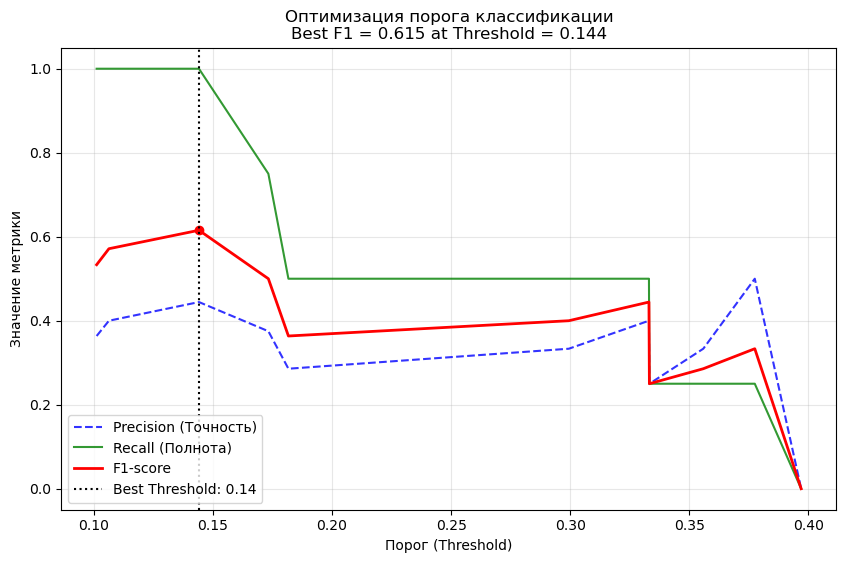


--- Сравнение порогов ---
           Standard (0.5)  Optimized
threshold        0.500000   0.144100
roc_auc          0.500000   0.500000
f1               0.000000   0.615385
precision        0.000000   0.444444
recall           0.000000   1.000000
accuracy         0.636364   0.545455


In [262]:
n_trials = 100
my_model, trials_history = run_gpu_pipeline((X_train, y_train_class), (X_test, y_test_class))

In [263]:
import pickle

# Сохранение через pickle (универсально для RF, XGB, LR)
model_filename = f"Models/{folder}/{data_name}_all_org_{emb_name}_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(my_model, f)

print(f"✅ Модель сохранена в файл: {model_filename}")

✅ Модель сохранена в файл: Models/Clearance/clearance_all_org_rdkit_model.pkl


In [17]:
import pandas as pd
import numpy as np
import cupy as cp
import optuna
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.svm import SVC as cuSVC # Исправил импорт
from sklearn.model_selection import StratifiedKFold
from cuml.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def get_metrics(y_true, y_prob):
    """Мультиклассовые метрики"""
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_prob, 'get'): y_prob = y_prob.get()
    
    # Получаем предсказания классов (индекс макс. вероятности)
    y_pred = np.argmax(y_prob, axis=1)
    
    return {
        # ROC-AUC для мультикласса (One-vs-Rest)
        'roc_auc': float(roc_auc_score(y_true, y_prob, multi_class='ovr')),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred))
    }

def plot_confusion_matrix(y_true, y_pred, save_path):
    """Визуализация матрицы ошибок вместо оптимизации порога"""
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_pred, 'get'): y_pred = y_pred.get()
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(save_path)
    plt.show()

In [18]:
import pandas as pd
import numpy as np
import cupy as cp
import optuna
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogReg
from sklearn.model_selection import StratifiedKFold
#from cuml.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, accuracy_score

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

def get_metrics(y_true, y_prob):
    """Исправленный расчет метрик через Scikit-learn"""
    # Переносим данные с GPU на CPU для совместимости с sklearn
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_prob, 'get'): y_prob = y_prob.get()
    
    # 1. Защита от пустых или сломанных предсказаний
    if y_prob is None or (isinstance(y_prob, np.ndarray) and y_prob.ndim == 1):
        return {'roc_auc': 0.5, 'f1': 0, 'precision': 0, 'recall': 0, 'accuracy': 0}

    # 2. Получаем классы (argmax)
    y_pred = np.argmax(y_prob, axis=1)
    
    try:
        return {
            # sklearn.metrics.roc_auc_score поддерживает multi_class='ovr'
            'roc_auc': float(roc_auc_score(y_true, y_prob, multi_class='ovr')),
            'f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
            'recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
            'accuracy': float(accuracy_score(y_true, y_pred))
        }
    except Exception as e:
        print(f"Metrics error: {e}")
        return {'roc_auc': 0.5, 'f1': 0, 'precision': 0, 'recall': 0, 'accuracy': 0}



def plot_and_optimize_threshold(y_true, y_probs, save_path=f"Models/{folder}/{data_name}_{emb_name}threshold_optimization.png"):
    """
    Находит лучший порог и строит графики Precision, Recall и F1.
    """
    if hasattr(y_true, 'get'): y_true = y_true.get()
    if hasattr(y_probs, 'get'): y_probs = y_probs.get()

    # 1. Вычисляем кривые
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Вычисляем F1-score для каждого порога
    # Добавляем маленькое число 1e-8, чтобы избежать деления на ноль
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    
    # Находим лучший порог (thresholds короче precisions на 1 элемент)
    best_idx = np.argmax(f1_scores[:-1]) 
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # 2. Визуализация
    plt.figure(figsize=(10, 6), dpi=100)
    
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Точность)', alpha=0.8)
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Полнота)', alpha=0.8)
    plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2, label='F1-score')
    
    # Отмечаем лучшую точку
    plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    plt.scatter([best_threshold], [best_f1], color='red')
    
    plt.title(f'Оптимизация порога классификации\nBest F1 = {best_f1:.3f} at Threshold = {best_threshold:.3f}')
    plt.xlabel('Порог (Threshold)')
    plt.ylabel('Значение метрики')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    
    plt.savefig(save_path)
    plt.show()
    
    return best_threshold


def run_gpu_pipeline(train_set, test_set):
    X_tr = cp.asarray(train_set[0], dtype=cp.float32)
    y_tr = cp.asarray(train_set[1], dtype=cp.float32)
    X_te = cp.asarray(test_set[0], dtype=cp.float32)
    y_te = cp.asarray(test_set[1], dtype=cp.float32)

    def objective(trial):
        cp.get_default_memory_pool().free_all_blocks()
        model_type = trial.suggest_categorical("model", ["RF", "XGB", "SVM"])
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Списки для хранения метрик по фолдам
        fold_results = []

        for train_idx, val_idx in skf.split(X_tr.get(), y_tr.get()):
            curr_X_train, curr_X_val = X_tr[train_idx], X_tr[val_idx]
            curr_y_train, curr_y_val = y_tr[train_idx], y_tr[val_idx]

            # Предполагаем, что train_idx — это индексы текущего фолда из StratifiedKFold
            # Веса должны соответствовать только обучающей части текущего фолда!
            curr_weights, _ = calculate_multiclass_weights(curr_y_train)
            
            try:
                if model_type == "RF":
                    model = cuRF(
                        n_estimators=trial.suggest_int("rf_n_estimators", 50, 500, log=True),
                        max_depth=trial.suggest_int("rf_max_depth", 5, 20),
                        # Важно: cuML RF может требовать числовое значение для max_features
                        max_features=trial.suggest_categorical("rf_max_features", ["sqrt", "log2", 0.8]),
                        min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 10),
                        random_state=42,
                        n_streams=1 # Ускоряет запуск малых моделей
                    )
                    # cuRF не поддерживает sample_weight в .fit(), обучаем без них
                    model.fit(curr_X_train, curr_y_train)
            
                elif model_type == "XGB":
                    model = XGBClassifier(
                        device="cuda",
                        tree_method="hist",
                        max_bin=128,
                        learning_rate=trial.suggest_float("xgb_learning_rate", 0.005, 0.2, log=True),
                        max_depth=trial.suggest_int("xgb_max_depth", 3, 10),
                        n_estimators=trial.suggest_int("xgb_n_estimators", 100, 1000),
                        subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
                        colsample_bytree=trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
                        min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 10),
                        random_state=42,
                        n_jobs=-1
                    )
                    # XGBoost идеально работает с весами
                    model.fit(curr_X_train, curr_y_train, sample_weight=curr_weights)
            
                else:  # SVM
                    model = cuSVC(
                        C=trial.suggest_float("svm_c", 0.1, 10.0, log=True),
                        gamma='scale',
                        kernel='rbf',
                        probability=True,
                        random_state=42
                    )
                    # cuSVC также может не принимать веса, обучаем классически
                    model.fit(curr_X_train, curr_y_train)
                    model._estimator_type = "classifier"

                probs = model.predict_proba(curr_X_val)

                # Специфический костыль для cuRF (GPU Random Forest)
                if model_type == "RF" and isinstance(probs, list):
                # Превращаем [array(N,), array(N,), array(N,)] в array(N, 3)
                    probs = cp.stack(probs, axis=1)
                # Получение вероятностей
                #probs = model.predict_proba(curr_X_val)[:, 1]
                
                # Расчет метрик (убедись, что get_metrics принимает вероятности для AUC)
                metrics = get_metrics(curr_y_val, probs)
                fold_results.append(metrics)
            
            except Exception as e:
                print(f"Ошибка в trial {trial.number}: {e}")
                raise optuna.exceptions.TrialPruned() # Пруним ошибочные итерации

        if not fold_results: return 0.0

        # Усредняем все метрики по фолдам и сохраняем их в trial
        avg_metrics = pd.DataFrame(fold_results).mean().to_dict()
        for metric_name, value in avg_metrics.items():
            trial.set_user_attr(metric_name, value)
        
        avg_metrics = pd.DataFrame(fold_results).mean().to_dict()
        return avg_metrics['f1']# Целевая метрика для оптимизации

    # 1. Запуск оптимизации
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, catch=(XGBoostError, MemoryError))

    # 2. Сохранение таблицы ВСЕХ попыток со ВСЕМИ метриками
    trials_df = study.trials_dataframe()
    # Колонки с метриками будут иметь префикс 'user_attrs_'
    trials_df.to_csv(f"Models/{folder}/{data_name}_{emb_name}_all_models_history_detailed.csv", index=False)
    print("Таблица всех попыток сохранена в 'all_models_history_detailed.csv'")

    # 3. Финальное обучение лучшей модели
    bp = study.best_params
    m_name = bp.pop("model")
    
    if m_name == "RF":
        final_model = cuRF(
        n_estimators=bp["rf_n_estimators"],
        max_depth=bp["rf_max_depth"],
        max_features=bp["rf_max_features"],
        min_samples_leaf=bp["rf_min_samples_leaf"],
        random_state=42
    )
    elif m_name == "XGB":
        final_model = XGBClassifier(
        device="cuda", 
        tree_method="hist", 
        max_bin=256,
        # Вручную сопоставляем лучшие параметры из Optuna с аргументами XGBoost
        n_estimators=bp["xgb_n_estimators"],
        learning_rate=bp["xgb_learning_rate"],
        max_depth=bp["xgb_max_depth"],
        subsample=bp["xgb_subsample"],
        colsample_bytree=bp["xgb_colsample_bytree"],
        min_child_weight=bp["xgb_min_child_weight"],
        random_state=42
        )
    else:
        final_model = cuSVC(C=bp["svm_c"], gamma=bp["svm_gamma"], kernel='rbf', probability=True)

    final_model.fit(X_tr, y_tr)

    # 1. Получаем вероятности (матрица N x 3)
    test_probs = final_model.predict_proba(X_te)
    
    # Костыль для cuRF на случай списка
    if m_name == "RF" and isinstance(test_probs, list):
        test_probs = cp.stack(test_probs, axis=1)

    # 2. Считаем метрики (стандартный порог для мультикласса — это просто argmax)
    # Функцию get_metrics_at_threshold нужно либо переписать под мультикласс, 
    # либо использовать вашу get_metrics
    final_results = get_metrics(y_te, test_probs)

    # Печатаем результат
    comparison_df = pd.DataFrame([final_results], index=['Final Model'])
    print("\n--- Результаты на тестовой выборке ---")
    print(comparison_df.T)
    
    # Оптимизацию порога (plot_and_optimize_threshold) лучше убрать для 3 классов,
    # так как она не имеет однозначного решения без выбора конкретного класса.
    
    return final_model, comparison_df

In [19]:
n_trials = 100
model, comparison = run_gpu_pipeline((X_train, y_train_class), (X_test, y_test_class))

[I 2026-02-07 18:26:02,508] A new study created in memory with name: no-name-b1afc640-270c-4ed8-8ef3-bd2c622eb8f1
[I 2026-02-07 18:26:12,851] Trial 0 finished with value: 0.5272942089542635 and parameters: {'model': 'RF', 'rf_n_estimators': 220, 'rf_max_depth': 9, 'rf_max_features': 0.8, 'rf_min_samples_leaf': 1}. Best is trial 0 with value: 0.5272942089542635.
[I 2026-02-07 18:26:34,136] Trial 1 finished with value: 0.5422898039032328 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.02457687962978734, 'xgb_max_depth': 7, 'xgb_n_estimators': 722, 'xgb_subsample': 0.8816768391795797, 'xgb_colsample_bytree': 0.6920631262072798, 'xgb_min_child_weight': 9}. Best is trial 1 with value: 0.5422898039032328.
[I 2026-02-07 18:27:00,377] Trial 2 finished with value: 0.5445315066452576 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.08058425235981663, 'xgb_max_depth': 5, 'xgb_n_estimators': 969, 'xgb_subsample': 0.5115101401703527, 'xgb_colsample_bytree': 0.8689231936848443, 'xgb_m

[2026-02-07 18:28:01.275] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:01.923] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:02.265] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:02.621] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:02.967] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-07 18:28:03,321] Trial 10 finished with value: 0.2690957408601352 and parameters: {'model': 'SVM', 'svm_c': 0.14871768904775368}. Best is trial 2 with value: 0.5445315066452576.
[I 2026-02-07 18:28:56,362] Trial 11 finished with value: 0.5521985537000176 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.005696979509428078, 'xgb_max_depth': 6, 'xgb_n_estimators': 974, 'xgb_subsample': 0.7296482431865652, 'xgb_colsample_bytree': 0.950720446934729, 'xgb_min_child_weight': 1}. Best is trial 11 with value: 0.5521985537000176.


[2026-02-07 18:28:56.369] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:56.734] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:57.099] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:57.487] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 18:28:57.879] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-07 18:28:58,265] Trial 12 finished with value: 0.32689653837782495 and parameters: {'model': 'SVM', 'svm_c': 9.304710141298434}. Best is trial 11 with value: 0.5521985537000176.
[I 2026-02-07 18:30:06,002] Trial 13 finished with value: 0.5530821789297785 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.005897706491392696, 'xgb_max_depth': 7, 'xgb_n_estimators': 974, 'xgb_subsample': 0.6789184856673978, 'xgb_colsample_bytree': 0.9536238072458011, 'xgb_min_child_weight': 1}. Best is trial 13 with value: 0.5530821789297785.
[I 2026-02-07 18:31:27,357] Trial 14 finished with value: 0.5539155626924869 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.005367381174937481, 'xgb_max_depth': 8, 'xgb_n_estimators': 957, 'xgb_subsample': 0.7123678501634854, 'xgb_colsample_bytree': 0.9757804573141555, 'xgb_min_child_weight': 1}. Best is trial 14 with value: 0.5539155626924869.
[I 2026-02-07 18:31:55,724] Trial 15 finished with value: 0.5514819542209988 and parameters: {'mode

...

[2026-02-07 19:04:55.079] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 19:04:55.770] [CUML] [warning] Random state is currently ignored by probabilistic SVC
[2026-02-07 19:04:56.203] [CUML] [warning] Random state is currently ignored by probabilistic SVC


[I 2026-02-07 19:04:56,495] Trial 87 pruned. 


Ошибка в trial 87: Invalid argument


[I 2026-02-07 19:05:44,295] Trial 88 finished with value: 0.5553130224523846 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.005957053276062729, 'xgb_max_depth': 10, 'xgb_n_estimators': 845, 'xgb_subsample': 0.5270777020167269, 'xgb_colsample_bytree': 0.8929813178056938, 'xgb_min_child_weight': 4}. Best is trial 77 with value: 0.5653404588794713.
[I 2026-02-07 19:06:25,321] Trial 89 finished with value: 0.5530787534405659 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.005699441237613854, 'xgb_max_depth': 9, 'xgb_n_estimators': 801, 'xgb_subsample': 0.5048488876620577, 'xgb_colsample_bytree': 0.9097635061815684, 'xgb_min_child_weight': 5}. Best is trial 77 with value: 0.5653404588794713.
[I 2026-02-07 19:07:14,549] Trial 90 finished with value: 0.5593832331122862 and parameters: {'model': 'XGB', 'xgb_learning_rate': 0.0065927400273424, 'xgb_max_depth': 10, 'xgb_n_estimators': 916, 'xgb_subsample': 0.5271589029552942, 'xgb_colsample_bytree': 0.8660184554059038, 'xgb_min_

Таблица всех попыток сохранена в 'all_models_history_detailed.csv'

--- Результаты на тестовой выборке ---
           Final Model
roc_auc       0.595102
f1            0.344112
precision     0.346674
recall        0.361997
accuracy      0.373333


In [20]:
comparison

,roc_auc,f1,precision,recall,accuracy
Final Model,0.595102,0.344112,0.346674,0.361997,0.373333


In [40]:
test_probs = model.predict(X_test)

In [20]:
y_pred

NameError: name 'y_pred' is not defined

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
test_probs = model.predict_proba(X_test)
y_pred = np.argmax(test_probs, axis=1)

print(y_pred)
# 1. Переносим на CPU и принудительно конвертируем в int
y_true_cpu = y_test_class.get().astype(int) if hasattr(y_test_class, 'get') else np.array(y_test_class).astype(int)
y_pred_cpu = y_pred.get().astype(int) if hasattr(y_pred, 'get') else np.array(y_pred).astype(int)

# 2. Строим матрицу ошибок
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_cpu, y_pred_cpu)

print("Confusion Matrix:\n", cm)

# Дополнительно: посмотрим, какие именно классы есть в предсказаниях
print("Уникальные классы в тесте: ", np.unique(y_true_cpu))
print("Уникальные классы в предсказаниях: ", np.unique(y_pred_cpu))

[0 0 1 1 2 2 1 1 1 0 0 1 1 0 1 1 2 0 1 0 1 0 1 1 2 1 2 2 1 0 0 0 1 1 0 1 1
 1 0 1 1 1 1 1 0 1 1 1 0 2 2 1 2 1 0 0 0 1 1 2 1 1 0 1 1 1 1 1 1 0 0 0 1 0
 0]
Confusion Matrix:
 [[ 9 15  1]
 [ 8 17  2]
 [ 7  9  7]]
Уникальные классы в тесте:  [0 1 2]
Уникальные классы в предсказаниях:  [0 1 2]


In [42]:
comparison.to_csv(f"Models/{folder}/{data_name}_{emb_name}_test_metrics_ml.csv")

In [76]:
import pickle

# Сохранение через pickle (универсально для RF, XGB, LR)
model_filename = f"Models/{folder}/{data_name}_{emb_name}_model_ml.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

print(f"✅ Модель сохранена в файл: {model_filename}")

✅ Модель сохранена в файл: Models/Half_life/Half_life_chemberta_model_ml.pkl


In [55]:
y_test

array([ 0.30103   ,  1.43136376, -0.48811664,  2.5390761 ,  0.11394335,
        1.        ,  0.14612804,  0.23044892, -0.52287875, -1.12493874,
        0.43136376,  0.30103   ,  0.54406804,  2.72263392,  0.59328607,
        1.92427929,  3.12723442, -0.4436975 , -0.04575749,  0.39794001,
        1.92427929, -0.48148606,  0.90848502, -1.79588002,  1.65321251,
        1.5563025 ,  2.18184359,  1.92941893, -1.23657201,  1.        ,
        1.95424251, -0.4436975 , -0.61978876, -1.39794001,  0.54406804,
       -1.30103   , -1.22184875, -0.12493874,  0.76342799, -0.60205999,
        1.07918125,  0.55840854,  0.76715587, -1.09691001,  1.38021124,
        0.30103   , -0.88605665, -1.09691001,  1.38021124,  0.77815125,
        1.38021124,  1.38021124,  1.77815125,  1.26951294, -1.04575749,
        0.17609126,  1.55870857,  0.43616265,  0.77815125, -0.88605665,
        1.07918125,  1.07918125,  0.88081359,  0.76937733, -0.12493874,
        0.        ,  0.        , -0.30103   , -1.09691001,  0.39